#### FPVS pypeline 2 pynt 0
This is the second edition of the FPVS pypeline where all processes/steps in the pipeline are functionalized so that they can be completed in a more streamlined manner in addition to this application being distributed as a package. 
steps 

1. Preprocess step 1

## Import libraries

In [27]:
%reset -f
import cust_funcs as cf
import FPVS_pycage as FPVS
from pathlib import Path
import importlib
# importlib.reload(FPVS)

## Preprocessing phase 1 
0. Remodelling the lw6 and mat data to make them more Python-friendly
1. Rename channels
2. Changing the channel locations and adding spherical coordinates to the meta (lw6) data
3. Downsampling the mat_data 
4. Deleting the EXG X and status channels
5. Bandpass and notch filtering

In [44]:
importlib.reload(cf)
importlib.reload(FPVS)
matfilepath = Path("D:\Goffaux lab\Data set\Python_CSVfiles\CHMA0501.mat")
lw6filepath = matfilepath.with_suffix(".lw6")
subjid = matfilepath.stem
mat_data, meta_data , metafilepath = FPVS.preprocessFPVSdata_phase1(matfilepath,lw6filepath)

the keys in old data are:  ('filetype', 'name', 'tags', 'history', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events')
the keys in the new data are:  dict_keys(['filetype', 'name', 'tags', 'history', 'origins', 'datasize', 'xstart', 'ystart', 'zstart', 'xstep', 'ystep', 'zstep', 'chanlocs', 'events', 'fs', 'activation', 'fields'])
D:\Goffaux lab\Data set\Python_CSVfiles\CHMA0501.pkl
data is saved as:  D:\Goffaux lab\Data set\Python_CSVfiles\CHMA0501.pkl


channels are renamed and saved in and as:  D:\Goffaux lab\Data set\Python_CSVfiles\1_chanlabels CHMA0501.pkl


elec. locations are changed! and saved as  D:\Goffaux lab\Data set\Python_CSVfiles\2_chanlocs 1_chanlabels CHMA0501


Data is downsampled! by a factor of  8  and saved as  D:\Goffaux lab\Data set\Python_CSVfiles\3_ds 2_chanlocs 1_chanlabels CHMA0501


channels being deleted are:  ['EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']

 data saved in  D:\Goffaux lab\Data set\Python_CSVfiles\4_chan-se

## Performing ICA 
Because jupyter is asynchronous, i have to split the perform_ICA, overlay ICA and apply ICA separately, in three different cells. 

In [39]:
print(metafilepath)

D:\Goffaux lab\Data set\Python_CSVfiles\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy


In [46]:
importlib.reload(FPVS)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')

print(metafilepath.exists())
print(metafilepath)
print(matfilepath)
ica, raw, ica_data, idx = FPVS.preprocessFPVSdata_performICA(matfilepath=matfilepath, metafilepath = metafilepath)

True
D:\Goffaux lab\Data set\Python_CSVfiles\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl
D:\Goffaux lab\Data set\Python_CSVfiles\6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy
Creating RawArray with float64 data, n_channels=68, n_times=921856
    Range : 0 ... 921855 =      0.000 ...  3600.996 secs
Ready.
length of dict: 68
Fitting ICA to data using 68 channels (please be patient, this may take a while)


C:\Users\Admin\anaconda_projects\FPVS Pypeline\FPVS_pycage.py:310: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by explained variance: 34 components
Fitting ICA took 102.7s.
Using EOG channel: Fp1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Up

## Overlay ICA data on actual activation

In [61]:
importlib.reload(FPVS)
FPVS.overlayICAondata(matfilepath,metafilepath,ica_data)

CHMA0501


## Apply ICA to the actual data. 

In [62]:
## rmidx is the variable where the Independent components with blink are stored and will be removed in the next cell
# rmidx = [0,2,3,7,8,9,10,12] #ADVI
rmidx = [0,2,3,5,6,9,11,13,15,16,17,18,19,20,21,23,24] # 24 looks dicey CHMA


In [64]:
importlib.reload(cf)
importlib.reload(FPVS)
mat_data, meta_data, metafilepath = FPVS.preprocessFPVSdata_applyICA(matfilepath, metafilepath, ica , raw, rmidx)

Removing ICA components: [0, 2, 3, 5, 6, 9, 11, 13, 15, 16, 17, 18, 19, 20, 21, 23, 24]
Applying ICA to Raw instance
    Transforming to ICA space (34 components)
    Zeroing out 17 ICA components
    Projecting back using 68 PCA components
ICA performed, data saved as  D:\Goffaux lab\Data set\Python_CSVfiles\ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501


## Interpolate channels

In [74]:
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
print(matfilepath)
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)
cf.showmeSignalUI(mat_data, meta_data,ylim=150)

D:\Goffaux lab\Data set\Python_CSVfiles\7_ep ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.npy
(68, 41, 17920)


In [ ]:
interp_chnames = ['P1','P3','PO3']
bad_chids = ['Fp1','CP6','I2']
print(labels)

In [ ]:
importlib.reload(FPVS)
mat_data,meta_data,metafile = FPVS.preprocessFPVSdata_phase2(matfilepath,metafilepath,interp_chnames=interp_chnames,bad_but_ignore=bad_chids)

## Segmenting the data 

In [71]:
importlib.reload(cf)
importlib.reload(FPVS)
print(metafilepath)
metafilepath = metafilepath.with_suffix('.pkl')
matfilepath = metafilepath.with_suffix('.npy')
mat_data, meta_data, metafilepath = FPVS.preprocesssFPVSdata_segmentation(matfilepath, metafilepath)

D:\Goffaux lab\Data set\Python_CSVfiles\ica_filt6_fft-notchfilter 5_but 4_chan-select 3_ds 2_chanlocs 1_chanlabels CHMA0501.pkl
Event label being split:  10
Event label being split:  45
Event label being split:  90
Event label being split:  135
Event label being split:  200
Event label being split:  210
Event label being split:  212
Event label being split:  214
Event label being split:  216
Event label being split:  218
Event label being split:  220
Event label being split:  222
Event label being split:  224


## Sanity checks

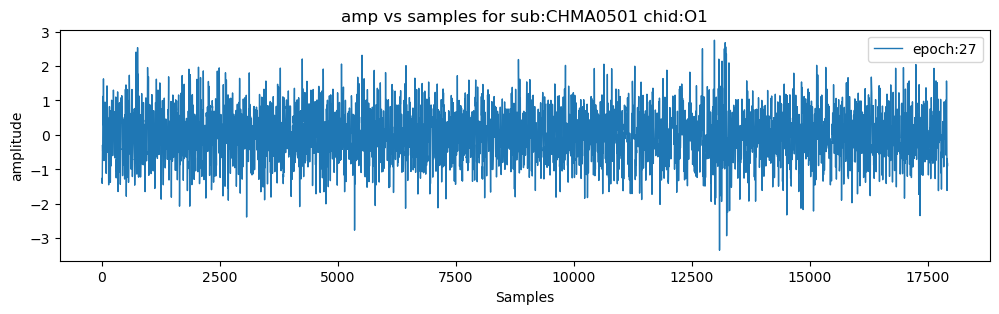

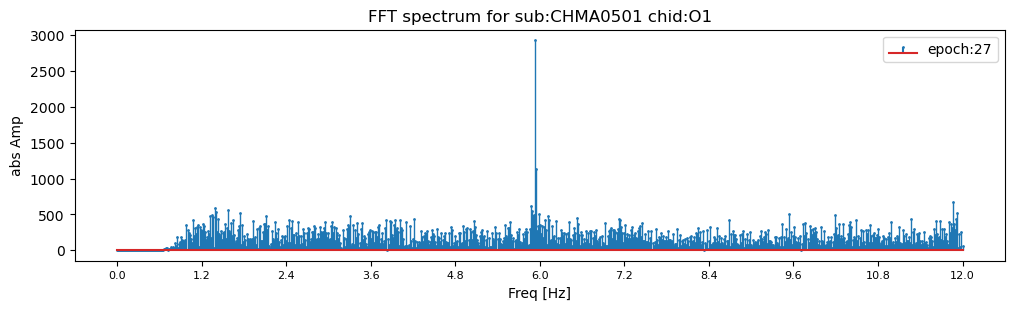

In [104]:
import numpy as np
importlib.reload(cf)
matfilepath = metafilepath.with_suffix('.npy')
metafilepath = metafilepath.with_suffix('.pkl')
mat_data = np.load(matfilepath)
meta_data = cf.loadMetadata(metafilepath)

fs = meta_data['fs']
chid = 26
subjid = matfilepath.stem.split()[-1]
epochid = 27
signal = mat_data[:,chid,epochid]
label = meta_data["chanlocs"]["labels"][chid]
cf.showmeSummaryPlot(signal = signal, fs = fs, chname = label, subjid = subjid,epochid = epochid,freqlim = [0, 12])

In [85]:
print(meta_data['chanlocs']['labels'])

['Fp1' 'AF7' 'AF3' 'F1' 'F3' 'F5' 'F7' 'FT7' 'FC5' 'FC3' 'FC1' 'C1' 'C3'
 'C5' 'T7' 'TP7' 'CP5' 'CP3' 'CP1' 'P1' 'P3' 'P5' 'P7' 'P9' 'PO7' 'PO3'
 'O1' 'Iz' 'Oz' 'POz' 'Pz' 'CPz' 'Fpz' 'Fp2' 'AF8' 'AF4' 'AFz' 'Fz' 'F2'
 'F4' 'F6' 'F8' 'FT8' 'FC6' 'FC4' 'FC2' 'FCz' 'Cz' 'C2' 'C4' 'C6' 'T8'
 'TP8' 'CP6' 'CP4' 'CP2' 'P2' 'P4' 'P6' 'P8' 'P10' 'PO8' 'PO4' 'O2' 'I1'
 'I2' 'PO9' 'PO10']


## Post processing 
1. FFT transform
2. averaging within trials
3. Frequency window chunking
4. Chunk selection( and splitting based on baseline and oddball chunks)
5. Sum of chunks/harmonics
6. baseline correction (I havent done SNR correction yet)

In [ ]:
odd_data, bl_data, oddfilepath, blfilepath = FPVS.postprocessFPVSdata("200", metafilepath.parent)